##위치 인코딩
T모델 입력 시퀀스를 병렬 처리 -> 단어 순서 정보를 위치 정보 벡터를 더해 임베딩 벡터에 위치 정보 반영

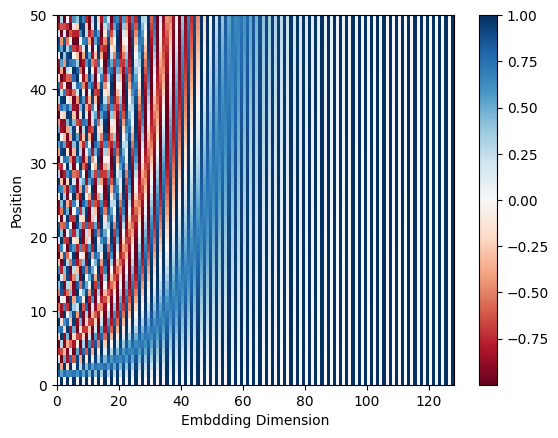

In [ ]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1): #임베딩 차원 d_model, 최대 시퀀스 max_len
    super().__init__()
    self.dropout=nn.Dropout(p=dropout)

    position=torch.arange(max_len).unsqueeze(1)
    div_term=torch.exp(
        torch.arange(0, d_model, 2)*(-math.log(10000.0)/d_model)
    )
    pe=torch.zeros(max_len, 1, d_model)
    pe[:,0,0::2]=torch.sin(position*div_term)
    pe[:,0,1::2]=torch.cos(position*div_term)
    self.register_buffer("pe", pe)

  def forward(self,x):
    x=x+self.pe[:,x.size(0)]
    return self.dropout(x)

encoding=PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(),cmap="RdBu")
plt.xlabel("Embdding Dimension")
plt.ylabel("Position")
plt.xlim((0,128))
plt.colorbar()
plt.show()

In [1]:
!python --version

Python 3.12.12


In [4]:
!pip uninstall torch torchvision torchaudio torchtext torchdata -y

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: torchdata 0.11.0
Uninstalling torchdata-0.11.0:
  Successfully uninstalled torchdata-0.11.0


In [5]:
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install torchtext==0.18.0 torchdata==0.8.0 portalocker>=2.0.0

!pip install datasets spacy
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 30.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 112.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 110.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 780.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.8.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 31.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 106.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all t

In [1]:
import torch
import torchtext
from torchtext.data.utils import get_tokenizer

print(f"PyTorch: {torch.__version__}")
print(f"torchtext: {torchtext.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

# 토크나이저 테스트
try:
    en_tokenizer = get_tokenizer('spacy', language='en_core_web_sm')
    print("torchtext 작동")
except Exception as e:
    print(f"실패: {e}")

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


PyTorch: 2.3.0+cu121
torchtext: 0.18.0+cpu
GPU 사용 가능: True
torchtext 작동


토치 데이터 및 토치 텍스트 라이브러리 설치

7.2 데이터셋 다운로드 및 전처리

In [2]:
# 독일어 말뭉치와 영어 말뭉치에 대해 각각 토크나이저와 어휘 사전 생성
from torchtext.datasets import Multi30k #dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

#사용자가 지정한 토크나이저를 가져오는 함수
def generate_tokens(text_iter, language):
  language_index={SRC_LANGUAGE:0, TGT_LANGUAGE:1}

  for text in text_iter:
    yield token_transform[language](text[language_index[language]])

SRC_LANGUAGE="de"
TGT_LANGUAGE="en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX=0,1,2,3
special_symbols=["<unk>", "<pad>", "<bos>", "<eos>"]
#spaCy 라이브러리로 사전 학습된 모델 -> token_transform 변수에 저장
token_transform={
    SRC_LANGUAGE:get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE:get_tokenizer("spacy", language="en_core_web_sm")
}
print("Token Transform")
print(token_transform)

vocab_transform={}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  train_iter=Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
  #토큰을 인덱스로 변환시키는 함수 저장
  #언어별 어휘 사전 생성
  vocab_transform[language]=build_vocab_from_iterator( #생성된 토큰을 이용해 단어집합 생성
      generate_tokens(train_iter, language),
      min_freq=1,
      specials=special_symbols, #특수 토큰
      special_first=True #True일 때 특수 토큰을 단어 집합의 맨 앞에 추가
  )
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)#어휘 사전에 없는 토큰인 <unk>의 인덱스를 할당

print("Vocab Transform:")
print(vocab_transform)

/usr/local/lib/python3.12/dist-packages/torchtext/datasets/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprec

Token Transform
{'de': functools.partial(<function _spacy_tokenize at 0x7b9760e3c9a0>, spacy=<spacy.lang.de.German object at 0x7b9745b3eff0>), 'en': functools.partial(<function _spacy_tokenize at 0x7b9760e3c9a0>, spacy=<spacy.lang.en.English object at 0x7b9745b1d910>)}


/usr/local/lib/python3.12/dist-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


Vocab Transform:
{'de': Vocab(), 'en': Vocab()}


7.3 트랜스포머 모델 구성

In [3]:
import math
import torch
from torch import nn

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout=nn.Dropout(p=dropout)

    position=torch.arange(max_len).unsqueeze(1)
    div_term=torch.exp(
        torch.arange(0, d_model,2)*(-math.log(10000.0)/d_model)
    )
    pe=torch.zeros(max_len, 1, d_model)
    pe[:,0,0::2]=torch.sin(position*div_term)
    pe[:,0,1::2]=torch.cos(position*div_term)
    self.register_buffer("pe", pe)

  def forward(self,x):
    x = x + self.pe[:x.size(0), :]
    return self.dropout(x)

class TokenEmbedding(nn.Module):
  def __init__(self, vocab_size,emb_size):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,emb_size)
    self.emb_size=emb_size

  def forward(self, tokens):
    return self.embedding(tokens.long())*math.sqrt(self.emb_size)
#TokenEmbedding 클래스로 소스 데이터와 입력 데이터를 입력 임베딩으로 변환, src_tok_emb, tgt_tok_emb를 생성
#소스와 타킷 데이터의 어휘 사전 크기 입력 -> 트랜스포머 임베딩 크기로 변환
class Seq2SeqTransformer(nn.Module):
  def __init__(
      self,
      num_encoder_layers,
      num_decoder_layers,
      emb_size,
      max_len,
      nhead,
      src_vocab_size,
      tgt_vocab_size,
      dim_feedforward,
      dropout=0.1,
               ):
    super().__init__()
    self.src_tok_emb=TokenEmbedding(src_vocab_size, emb_size)
    self.tgt_tok_emb=TokenEmbedding(tgt_vocab_size, emb_size)
    self.positional_encoding=PositionalEncoding(d_model=emb_size, max_len=max_len, dropout=dropout)
    self.transformer=nn.Transformer( #트랜스포머 블록
        d_model=emb_size,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout
        )
    self.generator=nn.Linear(emb_size, tgt_vocab_size)

  def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask,memory_key_padding_mask,):
    src_emb=self.positional_encoding(self.src_tok_emb(src))
    tgt_emb=self.positional_encoding(self.tgt_tok_emb(tgt))
    outs=self.transformer(
        src=src_emb,
        tgt=tgt_emb,
        src_mask=src_mask,
        tgt_mask=tgt_mask,
        memory_mask=None,
        src_key_padding_mask=src_padding_mask,
        tgt_key_padding_mask=tgt_padding_mask,
        memory_key_padding_mask=memory_key_padding_mask
    )
    return self.generator(outs) #T의 decoder에서 산출되는 벡터를 선형 변환->어휘 사전에 대한 로짓

  def encode(self, src, src_mask):
    return self.transformer.encoder(
        self.positional_encoding(self.src_tok_emb(src)),
        src_mask
    )
  def decode(self, tgt, memory, tgt_mask):
    return self.transformer.decoder(self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask)


######*파이토치의 트랜스포머 클래스

In [4]:
transformer=torch.nn.Transformer(
    d_model=512, #임베딩 차원 : 트랜스포머 모델의 입력과 출력 차원의 크기 & ==임베딩 차원 크기
    nhead=8, #멀티 헤드 어텐션 헤드의 개수, 모델의 병렬 처리 능력에 비례, but 모델 매개변수의 수도 증가
    num_encoder_layers=6, #인코더 계층 개수 : 인코더 계층 수
    num_decoder_layers=6, #디코더 계층 개수 : 디코더 계층 수 // 모델의 복잡도와 성능에 영향
    dim_feedforward=2048, #순방향 신경망 크기 : 순방향 신경망의 은닉층 크기 정의, 순방향 신경망 계층은 트랜스포머 계층의 각 입력 위치에 독립적으로 적용
    dropout=0.1, #드롭아웃
    activation=torch.nn.functional.relu, #활성화 함수
    layer_norm_eps=1e-05, #계층 정규화 입실론: 계층 정규화 수행시 분모에 더해지는 입실론 값
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


#####*트랜스포머 순방향 method

In [ ]:
output=transformer.forward(
    src,
    tgt, #소스와 타깃 : [소스(타깃) 시퀸스 길이, 배치 크기, 임베딩 차원]형태의 데이터를 받음
    src_mask=None,
    tgt_mask=None, #소스 마스크와 타깃 마스크 : [소스(타깃) 시퀸스 길이,시퀸스 길이]
    memory_mask=None,  #인코더 출력의 마스크 : [타깃 시퀸스 길이, 소스 시퀸스 길이],=0이면 어텐션 연산X
    #key padding : memory_key_padding_mask과 src_key_padding_mask는 동일한 형태의 데이터 입력받음
    src_key_padding_mask=None,
    tgt_key_padding_mask=None,
    memory_key_padding_mask=None,
    #마스크값 : 0>해당 위치 모든 입력 단어가 동일한 가중치&어텐션O,1>모든 입력 단어가 가중치 0&어텐션X, -inf>어텐션 연산 결과에 0으로 가중치, 마스킹된 위치의 정보를 모델이 무시
)

#####7.4 트랜스포머 모델 구조

In [5]:
from torch import optim

BATCH_SIZE=128
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

model=Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("ㄴ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("| ㄴ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("| | ㄴ", sssub_name)

cuda
src_tok_emb
ㄴ embedding
tgt_tok_emb
ㄴ embedding
positional_encoding
ㄴ dropout
transformer
ㄴ encoder
| ㄴ layers
| | ㄴ 0
| | ㄴ 1
| | ㄴ 2
| ㄴ norm
ㄴ decoder
| ㄴ layers
| | ㄴ 0
| | ㄴ 1
| | ㄴ 2
| ㄴ norm
generator


- Seq2SeqTransformer클래스 : 입력 임베딩+위치인코딩+트랜스포머 블록+로짓 생성
- 인코더와 디코더는 각각 3개
- 손실 함수 : 교차 엔트로피 함수
- ignore_index에 PAD_IDX 할당

#####7.5 배치 데이터 생성

In [6]:
# Multi30k 병목 현상;;
# 기존 꼬인 캐시 삭제
!rm -rf /root/.cache/torch/text/datasets/Multi30k



In [7]:
#파일 직접 다운로드
!mkdir -p ./data
!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.de.gz -O ./data/val.de.gz
!wget https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.en.gz -O ./data/val.en.gz
!gunzip -f ./data/val.de.gz
!gunzip -f ./data/val.en.gz

--2026-03-24 06:27:18--  https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.de.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24681 (24K) [application/octet-stream]
Saving to: ‘./data/val.de.gz’

./data/val.de.gz    100%[===================>]  24.10K  --.-KB/s    in 0s      

2026-03-24 06:27:18 (164 MB/s) - ‘./data/val.de.gz’ saved [24681/24681]

--2026-03-24 06:27:18--  https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.en.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 

In [8]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
# 여러개의 전처리 함수를 인자로 받아 적용하는 함수
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids): #특수 토큰 할당, BOS_IDX, EOS_IDX
    return torch.cat(
        (torch.tensor([BOS_IDX]),
         torch.tensor(token_ids),
         torch.tensor([EOS_IDX]))
    )
#집합함수, 배치 단위로 데이터 처리
def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch: #문자열 끝의 개행 문자 (\n)제거
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))
    #src와 tgt 시퀀스를 패딩
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], #각 문장 인덱스화
        vocab_transform[language], #각 토큰 인덱스화
        input_transform #특수 토큰 할당, BOS_IDX, EOS_IDX
    )
#데이터세트를 데이터로더에 적용
# 1. 파일을 읽어서 리스트로
def load_manual_data(src_path, tgt_path):
    data = []
    with open(src_path, 'r', encoding='utf-8') as f_src, \
         open(tgt_path, 'r', encoding='utf-8') as f_tgt:
        for s, t in zip(f_src, f_tgt):
            data.append((s.strip(), t.strip()))
    return data

# 2. 코드에 있던 변수명 'data_iter' 그대로 유지
data_iter = load_manual_data("./data/val.de", "./data/val.en")

# 3. 데이터로더 생성
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

# 4. 확인 코드
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")

print(next(iter(data_iter)))

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)
'''#(패딩이 적용된 소스, 패딩이 적용된 타깃) 튜플을 반환
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(next(iter(data_iter)))

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)'''

(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


'#(패딩이 적용된 소스, 패딩이 적용된 타깃) 튜플을 반환\ndataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)\nsource_tensor, target_tensor = next(iter(dataloader))\n\nprint("(source, target):")\nprint(next(iter(data_iter)))\n\nprint("source_batch:", source_tensor.shape)\nprint(source_tensor)\n\nprint("target_batch:", target_tensor.shape)\nprint(target_tensor)'

#####7.6 어텐션 마스크 생성

In [9]:
#마스크 생성 함수, s*s 크기의 마스크 생성
def generate_square_subsequent_mask(s):
    # 1로 채워진 행렬 -> 상삼각행렬 -> 전치
    mask = (torch.triu(torch.ones((s,s), device=DEVICE)) == 1).transpose(0,1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float('-inf')) #0이면 -inf로 > 셀프 어텐션에서 타깃 입력 시퀀스를 제외시키는 역할
        .masked_fill(mask == 1, float(0.0)) #1이면 0.0으로 > 셀프 어텐션에 참조되는 시퀀스를 가리킴
    )
    return mask
#타깃 시퀸스의 패딩 마스크 생성
def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0,1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0,1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

#b4 패딩 마스크 생성, 토큰 순서 한 칸 시프트 > 이전 토큰들로 다음 토큰 예측하도록
target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input)
# source_mask : 셀프 어텐션 과정에서 참조되는 소스 데이터의 시튄스 범위
# False : 해당 위치는 셀프 어텐션에 참조되는 토큰 / True : 어텐션에 제외되는 토큰
print("source_mask:", source_mask.shape)
print(source_mask)
# i번째 벡터는 i+1 이상의 키 벡터에 대해 어텐션 수행 X -> 이전 키에 대해서만 참조하는 특성
print("target_mask:", target_mask.shape)
print(target_mask)
# 소스(타깃) 배치 데이터에서 텍스트 토큰이 존재하는지 여부
# False : 해당 토큰 인덱스 존재 / True : 해당 토큰 인덱스가 패딩 토큰으로 채워짐
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf,

#####7.7 모델 학습 및 평가

In [10]:
# 모델 학습 및 평가를 위한 함수 > 소스와 타깃 데이터를 입력받아 collator로 문장들을 토큰화&인덱스로 변환
def run(model, optimizer, criterion, split):
    model.train() if split == 'train' else model.eval()
    data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]
        #create_mask는 입력 패딩 마스크와 어텐션 마스크 생성
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            tgt=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(
            logits.reshape(-1, logits.shape[-1]),
            target_output.reshape(-1))
        if split == 'train':
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(list(dataloader))

for epoch in range(5):
    train_loss = run(model, optimizer, criterion, 'train')
    val_loss = run(model, optimizer, criterion, 'valid')
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/datapipes/iter/combining.py:337: UserWarning: Some child DataPipes are not exhausted when __iter__ is called. We are resetting the buffer and each child DataPipe will read from the start again.
  warnings.warn("Some child DataPipes are not exhausted when __iter__ is called. We are resetting "


Epoch: 1, Train loss: 4.549, Val loss: 3.802
Epoch: 2, Train loss: 3.639, Val loss: 3.566
Epoch: 3, Train loss: 3.386, Val loss: 3.477
Epoch: 4, Train loss: 3.237, Val loss: 3.484
Epoch: 5, Train loss: 3.137, Val loss: 3.490


#####7.8 트랜스포머 모델 번역 결과

In [11]:
# 그리드 디코딩 방식 : 디코더 net가 생성한 확률 분포에서 가장 높은 확률을 가지는 단어 선택하여 디코딩 진행
# 현재까지 예측된 ㅌ큰 > 다음 토큰 예측
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)
    #model.encode : 소스 문장에 대한 인코딩 수행 > 마지막 인코더 트랜스포머 블록의 벡터 ㅜ출
    memory = model.encode(source_tensor, source_mask) # 마지막 인코더 트랜스포머 블록의 벡터
    #source_tensor(소스 문장을 토큰 인덱스로 표현)생성, source_mask : 모든 토큰이 어텐션이 되도록 -> 0으로 설정
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask) #어휘 사전에서 가장 높은 토큰 인덱스를 찾는다
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word())], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys

def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))

    return " ".join(output).replace("", "").replace("", "")

output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)


<bos> A group of people are standing in a room . <eos> . <eos> . <eos>
<bos> A group of people are standing in a room . <eos> . <eos> . <eos>
